## Import

In [1]:
import pandas as pd
merged_week_country = pd.read_csv(r"C:\Users\mkant\Documents\Intro to Python\CODE\LondonLab Data\merged_week_country.csv")#, #changing to without LOS
merged_week_country = merged_week_country[merged_week_country.COUNTRY == "Middle East - GCC"].drop(columns = 'Unnamed: 0')
merged_week_country['DATE'] = pd.to_datetime(merged_week_country['DATE'])

In [2]:
merged_week_country.columns

Index(['DATE', 'COUNTRY', 'TRANSACTIONS', 'ARRIVALS', 'LHR_arrivals',
       'non_LHR_arrivals', 'premium_economy_and_above_arrivals',
       'business_and_above_arrivals', 'first_arrivals',
       'transactions_non_target', 'transactions_target',
       'transactions_bronze_and_above', 'transactions_gold_and_above',
       'transactions_black_and_above', 'transactions_platinum_and_above',
       'transactions_elite_and_above'],
      dtype='object')

In [3]:
import numpy as np
merged_week_country['seasonal_sin'] = np.sin(2 * np.pi * merged_week_country['DATE'].dt.dayofyear / 365.25)

C:\Users\mkant\anaconda3\envs\londonlabtest\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 20, May, 2025
Time:                     19:37:57
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                    42.3854
Nobs:                     135.000    HQIC:                   42.2321
Log likelihood:          -3406.25    FPE:                1.97519e+18
AIC:                      42.1271    Det(Omega_mle):     1.80953e+18
--------------------------------------------------------------------
Results for equation transactions_gold_and_above
                                    coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------------------------
const                               -809.163379       244.799668           -3.305           0.001
L1.transactions_gold_and_above         0.633458         0.037461    

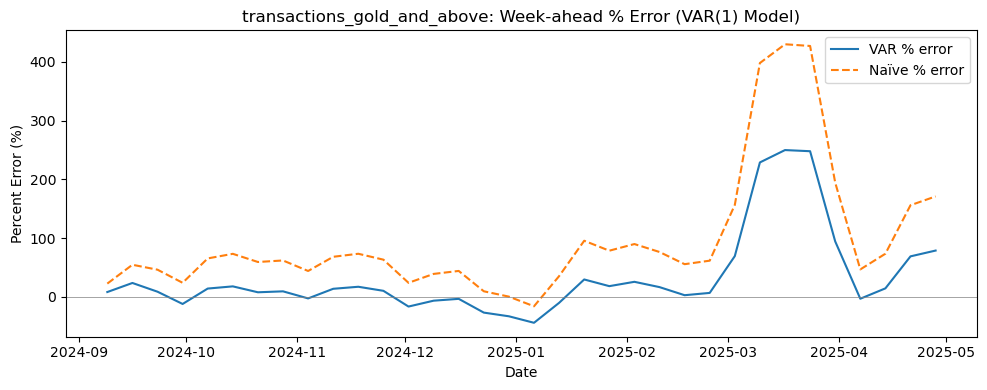

In [8]:
import pandas as pd
import numpy as np
from statsmodels.tsa.api import VAR
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

def var_forecast(
    df: pd.DataFrame,
    dep_var: str,
    endog_vars: list[str],
    lags: int = 2,
    test_frac: float = 0.2,
):
    # prepare
    df = df.copy()
    df["DATE"] = pd.to_datetime(df["DATE"])
    df = df.set_index("DATE")
    endog = df[endog_vars].astype(float).dropna()

    # split
    split = int(len(endog) * (1 - test_frac))
    train, test = endog.iloc[:split], endog.iloc[split:]

    # fit
    res = VAR(train).fit(lags)
    print(res.summary())

    # forecast
    fc_vals = res.forecast(train.values[-lags:], steps=len(test))
    fc = pd.DataFrame(fc_vals, index=test.index, columns=endog.columns)

    # errors
    # VAR percent error
    pct_var = (fc[dep_var] - test[dep_var]) / test[dep_var] * 100
    # naïve forecast: last observed value
    naive = pd.Series(train[dep_var].iloc[-1], index=test.index)
    pct_naive = (naive - test[dep_var]) / test[dep_var] * 100

    # scalar metrics
    rmse_var = np.sqrt(mean_squared_error(test[dep_var], fc[dep_var]))
    rmse_naive = np.sqrt(mean_squared_error(test[dep_var], naive))
    print(f"\nRMSE (VAR):       {rmse_var:.1f}")
    print(f"RMSE (naïve):     {rmse_naive:.1f}")
    print(f"Median % error:   {pct_var.median():.2f}%")
    print(f"Median % error (naïve): {np.median(pct_naive):.2f}%")

    # plot % error over time
    plt.figure(figsize=(10, 4))
    plt.plot(pct_var.index, pct_var, label="VAR % error", linestyle='-')
    plt.plot(pct_naive.index, pct_naive, label="Naïve % error", linestyle='--')
    plt.axhline(0, color='gray', linewidth=0.5)
    plt.title(f"{dep_var}: Week-ahead % Error (VAR({lags}) Model)")
    plt.ylabel("Percent Error (%)")
    plt.xlabel("Date")
    plt.legend()
    plt.tight_layout()
    plt.show()


# ---------------- example call ----------------
df = merged_week_country.copy()

var_forecast(
    df,
    dep_var="transactions_gold_and_above",
    endog_vars=[
        "transactions_gold_and_above",
        "LHR_arrivals",
        "business_and_above_arrivals",
        #"ARRIVALS"
    ],
    lags=1
)


In [5]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error

# ---------- 1. build features ----------
df = merged_week_country.copy().sort_values("DATE")
df["DATE"] = pd.to_datetime(df["DATE"])
df = df.set_index("DATE")

df["BA_0"] = df["business_and_above_arrivals"]            # same week
df["BA_1"] = df["business_and_above_arrivals"].shift(1)   # lag-1
df["BA_2"] = df["business_and_above_arrivals"].shift(2)   # lag-2

df["TR_3"] = df["transactions_gold_and_above"].shift(3)   # lag-3 (also naïve)

df = df.dropna()                                          # lose early rows

y  = df["transactions_gold_and_above"]
X  = sm.add_constant(df[[#"BA_0", 
                         "BA_1"
                         #,"BA_2"
                         ,"TR_3"
                         #, "TR_4"
                     ]])

# ---------- 2. train-test split (80/20, chronological) ----------
split = int(len(df) * 0.8)
X_tr,  X_te  = X.iloc[:split],  X.iloc[split:]
y_tr,  y_te  = y.iloc[:split],  y.iloc[split:]
naive_te     = df["TR_3"].iloc[split:]                    # lag-3 benchmark

# ---------- 3. fit OLS on training set ----------
model = sm.OLS(y_tr, X_tr).fit()

# ---------- 4. predict on test set ----------
y_pred = model.predict(X_te)

# ---------- 5. metrics on test set ----------
rmse_model = np.sqrt(mean_squared_error(y_te, y_pred))
rmse_naive = np.sqrt(mean_squared_error(y_te, naive_te))

pct_err_model = abs((y_pred  - y_te) / y_te * 100)
pct_err_naive = abs((naive_te - y_te) / y_te * 100)

print(model.summary())                       # full OLS summary
print(f"\n--- Out-of-sample metrics (last 20%) ---")
print(f"RMSE  OLS model : {rmse_model:.1f}")
print(f"RMSE  naive lag3: {rmse_naive:.1f}")
print(f"Mean abs % error   (model): {pct_err_model.mean():.2f}%")
print(f"Median abs % error   (model): {pct_err_model.median():.2f}%")
print(f"Mean  abs % error   (naive): {pct_err_naive.mean():.2f}%")
print(f"Median abs % error   (naive): {pct_err_naive.median():.2f}%")


                                 OLS Regression Results                                
Dep. Variable:     transactions_gold_and_above   R-squared:                       0.765
Model:                                     OLS   Adj. R-squared:                  0.761
Method:                          Least Squares   F-statistic:                     211.4
Date:                         Tue, 20 May 2025   Prob (F-statistic):           1.37e-41
Time:                                 19:26:20   Log-Likelihood:                -1158.3
No. Observations:                          133   AIC:                             2323.
Df Residuals:                              130   BIC:                             2331.
Df Model:                                    2                                         
Covariance Type:                     nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

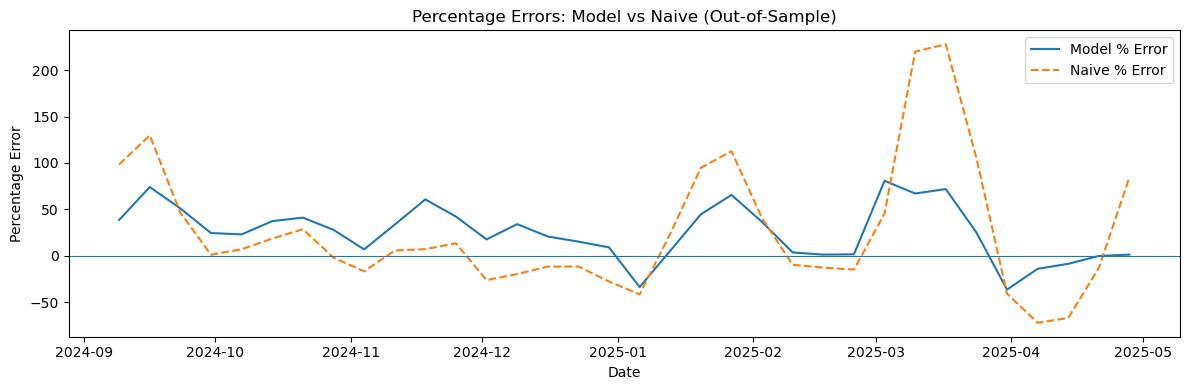

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm

# --- Load and prepare the data (replace with your DataFrame if different) ---
df = merged_week_country.copy().sort_values("DATE")
df["DATE"] = pd.to_datetime(df["DATE"])
df = df.set_index("DATE")

# Create required lags
df["BA_1"] = df["business_and_above_arrivals"].shift(1)
df["TR_3"] = df["transactions_gold_and_above"].shift(3)

# Drop rows with NaNs introduced by shifting
df = df.dropna()

y = df["transactions_gold_and_above"]
X = sm.add_constant(df[["BA_1", "TR_3"]])

# Chronological 80/20 split
split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# Fit OLS model
ols_model = sm.OLS(y_train, X_train).fit()

# Predictions
y_pred = ols_model.predict(X_test)

# Naive prediction (lag-3)
naive_pred = df["TR_3"].iloc[split:]

# Percentage errors
pct_err_model = (y_pred - y_test) / y_test * 100
pct_err_naive = (naive_pred - y_test) / y_test * 100

# --- Plotting ---
plt.figure(figsize=(12, 4))
plt.plot(pct_err_model.index, pct_err_model.values, label="Model % Error")
plt.plot(pct_err_naive.index, pct_err_naive.values, label="Naive % Error", linestyle="--")
plt.axhline(0, linewidth=0.8)
plt.xlabel("Date")
plt.ylabel("Percentage Error")
plt.title("Percentage Errors: Model vs Naive (Out-of-Sample)")
plt.legend()
plt.tight_layout()
plt.show()


In [8]:
import pandas as pd
import numpy as np
from statsmodels.tsa.api import VAR
from sklearn.metrics import mean_squared_error

# Assuming vars_df exists from previous canvas, with datetime index and no NaNs

def rolling_var_vs_naive(df, maxlags=4, rolling_window=52):
    """
    Performs a rolling one-step-ahead forecast comparing VAR against naive.
    rolling_window: number of weeks in each rolling training window (default 52).
    Returns: DataFrame with actual, var_pred, naive_pred, and error metrics.
    """
    actual = []
    var_preds = []
    naive_preds = []

    # Loop over forecast points
    for end_train in range(rolling_window, len(df)):
        train = df.iloc[end_train-rolling_window:end_train]
        test_val = df.iloc[end_train]['transactions_gold_and_above']

        # Fit VAR on training window
        model = VAR(train)
        fitted = model.fit(maxlags=maxlags)

        # Forecast one step ahead
        lag_order = fitted.k_ar
        input_data = train.values[-lag_order:]
        fc = fitted.forecast(y=input_data, steps=1)
        var_pred = fc[0][df.columns.get_loc('transactions_gold_and_above')]

        # Naive: last observed in train
        naive_pred = train['transactions_gold_and_above'].iloc[-1]

        actual.append(test_val)
        var_preds.append(var_pred)
        naive_preds.append(naive_pred)

    # Compile results
    results = pd.DataFrame({
        'actual': actual,
        'var_pred': var_preds,
        'naive_pred': naive_preds
    }, index=df.index[rolling_window:])

    # Compute RMSEs
    rmse_var = np.sqrt(mean_squared_error(results['actual'], results['var_pred']))
    rmse_naive = np.sqrt(mean_squared_error(results['actual'], results['naive_pred']))

    # Improvement
    improvement = rmse_naive - rmse_var
    pct_improvement = improvement / rmse_naive * 100

    metrics = {
        'rmse_var': rmse_var,
        'rmse_naive': rmse_naive,
        'rmse_improvement': improvement,
        'pct_improvement': pct_improvement
    }

    return results, metrics

# Enforce weekly frequency to avoid warnings
vars_df = vars_df.asfreq('W-MON')

# Execute rolling evaluation
test_results, test_metrics = rolling_var_vs_naive(vars_df)

# Display metrics
rmse_var = test_metrics['rmse_var']
rmse_naive = test_metrics['rmse_naive']
improvement = test_metrics['rmse_improvement']
pct_imp = test_metrics['pct_improvement']
avg_abs_imp = np.mean(np.abs(test_results['naive_pred'] - test_results['actual']) - np.abs(test_results['var_pred'] - test_results['actual']))

print(f"Rolling VAR(4) RMSE: {rmse_var:.3f}")
print(f"Rolling Naive RMSE: {rmse_naive:.3f}")
print(f"Absolute RMSE Improvement: {improvement:.3f} transactions")
print(f"Percent RMSE Improvement: {pct_imp:.2f}%")
print(f"Average weekly error reduction: {avg_abs_imp:.1f} transactions")


Rolling VAR(4) RMSE: 1402.302
Rolling Naive RMSE: 1550.989
Absolute RMSE Improvement: 148.687 transactions
Percent RMSE Improvement: 9.59%
Average weekly error reduction: 26.4 transactions


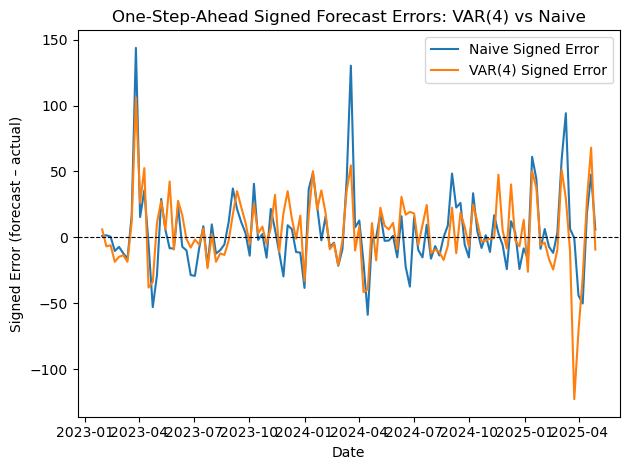

In [16]:
import matplotlib.pyplot as plt

# Compute signed errors: forecast minus actual
# Compute signed percentage errors: (forecast - actual) / actual
results['error_var_signed']   = (results['var_pred'] - results['actual']) / results['actual'] * 100
results['error_naive_signed'] = (results['naive_pred'] - results['actual']) / results['actual'] * 100


# Plot signed error series
plt.figure()
plt.plot(results.index, results['error_naive_signed'], label='Naive Signed Error')
plt.plot(results.index, results['error_var_signed'],   label='VAR(4) Signed Error')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Date')
plt.ylabel('Signed Error (forecast – actual)')
plt.title('One-Step-Ahead Signed Forecast Errors: VAR(4) vs Naive')
plt.legend()
plt.tight_layout()
plt.show()


In [15]:
import pandas as pd
import numpy as np
from sklearn.linear_model import MultiTaskLassoCV
from sklearn.model_selection import TimeSeriesSplit

# 1) Build lagged feature matrix up to p=4
p = 4
df_reg = vars_df.copy()
for lag in range(1, p+1):
    lagged = vars_df[['transactions_gold_and_above','LHR_arrivals','business_and_above_arrivals']].shift(lag)
    lagged.columns = [f"{col}_L{lag}" for col in lagged.columns]
    df_reg = pd.concat([df_reg, lagged], axis=1)

df_reg = df_reg.dropna()

# Define Y and X
target_cols = ['transactions_gold_and_above','LHR_arrivals','business_and_above_arrivals']
feature_cols = [c for c in df_reg.columns if c not in target_cols]

Y = df_reg[target_cols].values            # shape (n_samples, 3)
X = df_reg[feature_cols].values           # shape (n_samples, 12)

# 2) TimeSeries split for CV
tscv = TimeSeriesSplit(n_splits=5)

# 3) Fit MultiTaskLasso with built-in CV
mtl = MultiTaskLassoCV(cv=tscv, n_jobs=-1)
mtl.fit(X, Y)

# 4) Inspect coefficients
# mtl.coef_ has shape (n_tasks=3, n_features=12)
coef = pd.DataFrame(
    mtl.coef_,
    index=target_cols,
    columns=feature_cols
)
print(coef)

# 5) One-step forecast example
last_row = df_reg[feature_cols].iloc[-1].values.reshape(1, -1)
y_pred = mtl.predict(last_row)
display("Lasso-VAR forecast (transactions_gold_and_above, LHR_arrivals, business_and_above_arrivals):")
display(y_pred[0])



                             transactions_gold_and_above_L1  LHR_arrivals_L1  \
transactions_gold_and_above                        0.635125         0.139432   
LHR_arrivals                                      -0.669358         0.495225   
business_and_above_arrivals                       -0.059317        -0.001302   

                             business_and_above_arrivals_L1  \
transactions_gold_and_above                        0.429403   
LHR_arrivals                                       1.501457   
business_and_above_arrivals                        0.756429   

                             transactions_gold_and_above_L2  LHR_arrivals_L2  \
transactions_gold_and_above                             0.0        -0.003686   
LHR_arrivals                                            0.0         0.016276   
business_and_above_arrivals                             0.0        -0.000426   

                             business_and_above_arrivals_L2  \
transactions_gold_and_above               

'Lasso-VAR forecast (transactions_gold_and_above, LHR_arrivals, business_and_above_arrivals):'

array([ 3315.37758016, 11706.3238469 ,  1989.3819313 ])